# Water Quality Index — `epa-full.csv`

**Input:** `data/03c_merge_tertiary/epa-full.csv` — the terminal (T1) modeling table from the
merge pipeline (`MERGE.md`). One row per water-quality observation
(`MonitoringLocationIdentifier` × `ActivityStartDateTime`).

**Output:** three new columns written back into the same file —

| Column | Meaning |
|---|---|
| `WQI` | Water Quality Index, **0 = best, 100 = worst**, for that sample (same day, same location) |
| `WQI_n_groups` | how many of the eight pollution groups the sample actually measured |
| `WQI_weight_coverage` | the share of total index weight those groups carry (0–1) |

The two companion columns are not decoration. A WQI built from three measurements and a WQI
built from twelve are both on a 0–100 scale but they are not the same quantity, and anything
downstream — a model, a map, a trend line — needs to be able to tell them apart or filter on
them.

**Scope.** The three EDA notebooks that precede this one
([univariate](univariate-analysis.ipynb), [bivariate](bivariate-analysis.ipynb),
[multivariate](multivariate-analysis.ipynb)) describe the table as it is. This notebook adds
something to it: a single number per sample that summarises *how degraded the water was*,
across all the chemistry, biology and physics measured on that day at that place.

Building it is a modelling decision, not a lookup. There is no single accepted WQI — there is a
fifty-year literature of them, each with different parameters, different weights, different
aggregation algebra and different failure modes. Section 2 surveys that literature, section 3
screens the candidates against what this dataset can actually supply, and sections 4–9 build,
stress-test and select one.

---

## The three problems this dataset creates

Any WQI published in the literature assumes a fixed panel of parameters measured on every
sample. This table violates that assumption three separate ways, and each one kills a family of
standard methods:

1. **No sample measures everything.** The mean row carries 6.7 of the 23 possible measurements.
   9,180 rows carry exactly one. A fixed-panel index would be null on almost every row.
2. **Missingness is structured, not random.** There are at least two distinct sampling programs
   in here — a nutrient-chemistry panel and a full-suite ambient panel — and a bacteria-only
   program. Nitrate and E. coli co-occur on **161 rows out of 48,251**. Whatever the index does,
   it must not make "this station runs the nutrient panel" look like "this station is polluted".
3. **The measured parameters are heavily redundant.** Nitrate, nitrite, nitrate+nitrite,
   ammonia and Kjeldahl nitrogen are five views of nitrogen; orthophosphate,
   phosphate-phosphorus and total phosphorus are three views of phosphorus; chloride, sulfate,
   TDS and specific conductance are four views of dissolved salt. Averaging all 23 would weight
   nitrogen five times and pathogens once.

## 0. Setup

In [1]:
import json
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")

# Locate the repo root from wherever the kernel was started.
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "data" / "03c_merge_tertiary").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

DATA_PATH = REPO_ROOT / "data" / "03c_merge_tertiary" / "epa-full.csv"
OUT_DIR = REPO_ROOT / "src" / "04_eda" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("repo root :", REPO_ROOT)
print("data file :", DATA_PATH.relative_to(REPO_ROOT), f"({DATA_PATH.stat().st_size / 1e6:.1f} MB)")
print("outputs   :", OUT_DIR.relative_to(REPO_ROOT))

repo root : /Users/owenm/Documents/Owens_files/College Stuff/Research Projects/STEEN/workspace/Water-Quality-Prediction
data file : data/03c_merge_tertiary/epa-full.csv (80.8 MB)
outputs   : src/04_eda/outputs


### Plot style

The same recessive style as the other three notebooks: one hue for magnitude, a diverging
blue–gray–red ramp for anything signed, thin marks, a muted grid behind the data.

In [2]:
SURFACE   = "#ffffff"
INK       = "#0b0b0b"
INK_SOFT  = "#52514e"
GRIDLINE  = "#dcdbd6"
AXISLINE  = "#b8b7b2"

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA, GOLD, PINK, GREEN, PURPLE, RED = SERIES

# Quality ramp: green (clean) -> gold -> red (degraded). Used for the index itself,
# which is directional, so a sequential-through-warning ramp is the honest form.
QUALITY = LinearSegmentedColormap.from_list("wq_quality", [
    "#1a7f4e", "#5aab5a", "#a8c95c", "#e8cc5a", "#e89a3c", "#d4592e", "#9e2020",
]).copy()
QUALITY.set_bad("#e8e7e3")

DIVERGING = LinearSegmentedColormap.from_list("wq_div", [
    "#0d366b", "#1c5cab", "#2a78d6", "#86b6ef", "#cde2fb",
    "#f0efec",
    "#fbd2d1", "#f19392", "#e34948", "#b32f2e", "#7a1c1b",
]).copy()
DIVERGING.set_bad(SURFACE)

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": AXISLINE,
    "axes.labelcolor": INK_SOFT,
    "axes.titlecolor": INK,
    "axes.titlesize": 10,
    "axes.titleweight": "medium",
    "axes.labelsize": 8.5,
    "text.color": INK,
    "xtick.color": INK_SOFT,
    "ytick.color": INK_SOFT,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.frameon": False,
    "figure.dpi": 110,
    "savefig.dpi": 110,
})


def style_axes(ax, axis="y"):
    """Recessive grid + two spines. Grid sits behind the marks."""
    ax.grid(axis=axis, color=GRIDLINE, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_linewidth(0.8)
    ax.tick_params(length=0)
    return ax


def thousands(ax, axis="y"):
    fmt = FuncFormatter(lambda v, _: f"{v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)
    return ax

## 1. What the table actually measures

In [3]:
HEADER = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
MEASURED = [c for c in HEADER if c.endswith("_value")]

ID_COLS = ["MonitoringLocationIdentifier", "ActivityStartDateTime",
           "LatitudeMeasure", "LongitudeMeasure", "HUCEightDigitCode", "county_fips"]
CONTEXT_COLS = ["pct_corn", "pct_row_crops", "pct_developed", "streamflow_discharge_cfs",
                "prism_ppt_mm", "prism_tmax_c", "npdes__any_impaired", "npdes__n_impaired_303d"]

raw = pd.read_csv(
    DATA_PATH,
    usecols=ID_COLS + CONTEXT_COLS + MEASURED + [c.replace("_value", "_unit") for c in MEASURED],
    low_memory=False,
)
raw["ActivityStartDateTime"] = pd.to_datetime(raw["ActivityStartDateTime"], errors="coerce", utc=True)

inventory = pd.DataFrame({
    "unit": [raw[c.replace("_value", "_unit")].dropna().iloc[0] if raw[c.replace("_value", "_unit")].notna().any() else "—"
             for c in MEASURED],
    "n": [pd.to_numeric(raw[c], errors="coerce").notna().sum() for c in MEASURED],
}, index=[c.replace("_value", "") for c in MEASURED])
inventory["coverage_%"] = (100 * inventory["n"] / len(raw)).round(1)
inventory = inventory.sort_values("n", ascending=False)

print(f"{len(raw):,} rows   {raw.MonitoringLocationIdentifier.nunique():,} stations   "
      f"{raw.ActivityStartDateTime.dt.year.min():.0f}–{raw.ActivityStartDateTime.dt.year.max():.0f}")
inventory

48,251 rows   1,345 stations   2015–2025


,unit,n,coverage_%
"Temperature, water",deg C,34705,71.9
pH,std units,32353,67.1
Dissolved oxygen (DO),mg/L,31825,66
Orthophosphate,mg/L as P,22204,46
Turbidity,NTU,21156,43.8
Chloride,mg/L,20395,42.3
Total dissolved solids,mg/L,18011,37.3
Specific conductance,uS/cm,16067,33.3
Escherichia coli,MPN/100mL,15898,32.9
Total suspended solids,mg/L,14525,30.1


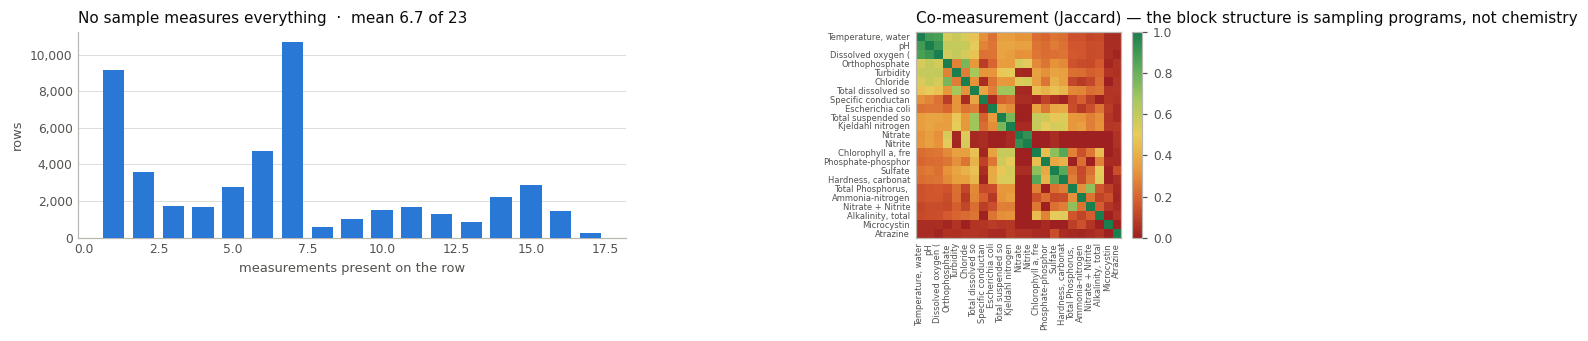

In [4]:
per_row = raw[MEASURED].apply(pd.to_numeric, errors="coerce").notna().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))

ax = axes[0]
counts = per_row.value_counts().sort_index()
ax.bar(counts.index, counts.values, color=BLUE, width=0.72, zorder=3)
ax.set_xlabel("measurements present on the row")
ax.set_ylabel("rows")
ax.set_title(f"No sample measures everything  ·  mean {per_row.mean():.1f} of {len(MEASURED)}", loc="left")
style_axes(ax); thousands(ax)

ax = axes[1]
M = raw[MEASURED].apply(pd.to_numeric, errors="coerce").notna().astype(int)
order = M.sum().sort_values(ascending=False).index
jac = (M[order].T @ M[order])
denom = np.add.outer(M[order].sum().values, M[order].sum().values) - jac.values
im = ax.imshow(np.where(denom > 0, jac.values / np.maximum(denom, 1), np.nan),
               cmap=QUALITY.reversed(), vmin=0, vmax=1)
short = [c.replace("_value", "")[:18] for c in order]
ax.set_xticks(range(len(order))); ax.set_xticklabels(short, rotation=90, fontsize=5.5)
ax.set_yticks(range(len(order))); ax.set_yticklabels(short, fontsize=5.5)
ax.set_title("Co-measurement (Jaccard) — the block structure is sampling programs, not chemistry", loc="left")
ax.tick_params(length=0)
fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)

fig.tight_layout()
plt.show()

The right panel is the whole problem in one image. The bright block in the upper left is the
routine physical panel (temperature, DO, pH, conductance, chloride). The nutrient panel and the
bacteria/solids panel are separate bright blocks that barely touch each other. A WQI that
requires all parameters returns nothing; a WQI that averages whatever is present has to be told
that these blocks are not interchangeable.

## 2. Survey of published WQI methods

Every method below reduces a vector of measurements to one number. They differ in four places:
**which parameters**, **how each is rescaled** (the sub-index or "rating curve"), **how the
sub-indices are weighted**, and **how they are aggregated**. The aggregation choice is the one
that matters most, because it decides what the index does when one parameter is catastrophic
and the rest are fine.

| Method | Parameters | Sub-index | Weights | Aggregation | Direction |
|---|---|---|---|---|---|
| **NSF WQI** (Brown et al. 1970) | fixed 9: DO %sat, fecal coliform, pH, BOD₅, ΔT, total phosphate, nitrate, turbidity, total solids | expert-elicited rating curves (Delphi panel of 142 experts) | Delphi: DO .17, coliform .16, pH .11, BOD .11, ΔT .10, PO₄ .10, NO₃ .10, turbidity .08, solids .07 | weighted arithmetic mean (or geometric variant) | 100 = best |
| **Oregon WQI** (Cude 2001) | fixed 8: T, DO, BOD, pH, NH₃+NO₃-N, TP, total solids, fecal coliform | published closed-form sub-index equations | none (deliberately unweighted) | **unweighted harmonic square mean** — `√(n / Σ 1/SI²)` | 100 = best |
| **Weighted Arithmetic WQI** (Horton 1965; Brown 1972) | any | `q = 100·(V−V_ideal)/(S−V_ideal)`, linear vs. a standard `S` | `w = 1/S`, normalised — inverse of the standard | `Σ q·w / Σ w` | higher = worse, unbounded |
| **CCME WQI** (CCME 2001) | any | none — binary pass/fail vs. an objective, plus an excursion magnitude | none | `100 − √(F1²+F2²+F3²)/1.732` over **scope**, **frequency**, **amplitude** | 100 = best |
| **Entropy-weighted WQI** (EWQI) | any | as weighted arithmetic | Shannon entropy of the data — objective, no expert input | weighted arithmetic mean | higher = worse |
| **Bhargava index** (1985) | use-dependent | sensitivity functions per intended use | none | geometric mean of sub-indices | 100 = best |
| **Overall Index of Pollution** (Sargaonkar & Deshpande 2003) | any | class-based piecewise curve, 1–5 pollution classes | none | arithmetic mean of pollution scores | higher = worse |

**Two structural failure modes** run through this table and name themselves in the literature:

- **Eclipsing** — the index reads acceptable while one parameter is severely out of compliance,
  because the arithmetic mean averaged it away. Pure arithmetic aggregation (NSF, weighted
  arithmetic, EWQI) is vulnerable.
- **Ambiguity** — the index reads bad while no individual parameter is out of compliance,
  because many mediocre values compounded. Multiplicative and harmonic aggregation (Bhargava,
  Oregon) are vulnerable.

Oregon's harmonic square mean is an explicit answer to eclipsing: the reciprocal-square term
lets the single worst sub-index dominate. That is the property this dataset needs, because
"E. coli at 20,000 MPN/100 mL and everything else normal" is a real and common state of an Iowa
stream after rain, and no index should call that water fine.

### 2.1 Screening the methods against this dataset

Four hard constraints, applied in order:

| Method | Fixed panel available? | Verdict |
|---|---|---|
| **NSF WQI** | ✗ needs **BOD₅** and **ΔT from 1 mile upstream** — neither exists in this table, and fecal coliform is only available as E. coli | **rejected as-is.** Its weighting philosophy is reusable; its parameter list is not. |
| **Oregon WQI** | ✗ needs **BOD** and **fecal coliform** | **rejected as-is.** Its *aggregation* is reusable and is tested in §7. |
| **CCME WQI** | ✗ F2 (frequency) and F3 (amplitude) are defined over **a set of samples through time**. On a single sample every variable is tested exactly once, so F1 ≡ F2 and the index collapses to a function of scope and excursion only. CCME's own guidance asks for ≥4 variables sampled ≥4 times each. | **rejected for the per-sample column.** Retained in §8 as an independent **per-station** benchmark to validate whatever we do build. |
| **Weighted Arithmetic** | ✓ works with any parameter set | **viable**, but `w = 1/S` is unusable here: standards span 0.076 mg/L (phosphorus) to 2,420 MPN/100 mL (E. coli), so inverse-standard weighting would hand phosphorus ~30,000× the weight of bacteria. Weights must come from somewhere else. |
| **EWQI** | ✓ | **rejected.** Entropy weights are computed from the observed spread of each parameter, and here that spread is confounded with which sampling program ran. Parameters measured only by the full-suite programme would receive weights reflecting programme design, not ecological importance. It would also make the weights unstable as new data arrives. |
| **OIP / Bhargava** | ✓ | **viable** but both are unweighted, which the redundancy problem (five nitrogen species, one pathogen) makes untenable without grouping. |

**Conclusion.** No published index transfers unmodified. What survives screening is a
*composition*: the **weighted-arithmetic skeleton** (works with any parameter set), **NSF's
severity-based weighting philosophy** (not its parameter list), **Oregon's worst-parameter
sensitivity** (not its fixed panel), and **regulatory thresholds as the sub-index anchors**
(rather than expert Delphi curves, which do not exist for these 23 parameters). Two additions
are forced by this dataset and appear in no published method: **grouping to control redundancy**
(§5) and an **explicit minimum-data rule** (§6).

## 3. Reference thresholds

Every sub-index needs an anchor: a value at which the water stops being clean. Since we have no
Delphi panel, the anchors are **published regulatory criteria and reference conditions**, each
cited. Three anchor kinds are used:

- **background** — the value below which the parameter is not a concern at all → sub-index `0`
- **reference** — the ecoregional reference condition, i.e. the natural background of least-disturbed
  streams in this region → sub-index `25`
- **criterion** — the regulatory threshold → sub-index **`50`**
- **severe** — gross impairment, typically 3–6× the criterion → sub-index `100`

Anchoring the criterion at exactly 50 makes the finished index readable without a lookup table:
**WQI below 50 means the sample was, on balance, within its standards; above 50 means it was
not.**

Sources: Iowa Administrative Code 567—61.3 (surface water quality criteria); US EPA National
Primary and Secondary Drinking Water Regulations (MCLs / SMCLs); US EPA *Ambient Water Quality
Criteria Recommendations, Ecoregion VI: Corn Belt and Northern Great Plains* (EPA 822-B-00-017,
2000) for reference conditions; US EPA *Aquatic Life Ambient Water Quality Criteria for Ammonia
— Freshwater* (2013); US EPA recreational water quality criteria for cyanotoxins (2019).

In [5]:
# value -> sub-index anchors.  q: 0 = pristine, 50 = at the regulatory criterion, 100 = severe.
# scale="log" interpolates on log10(value) — used for the parameters whose distributions span
# orders of magnitude (E. coli spans 0 to 2.4e6; turbidity 0 to 3,510).

CURVES = {
    # ── oxygen ────────────────────────────────────────────────────────────────────────
    "Dissolved oxygen (DO)_value": dict(
        scale="linear", anchors=[(2, 100), (3, 80), (5, 50), (7, 20), (9, 0)],
        source="IAC 567—61.3 Class B(WW) minimum 5.0 mg/L; 2 mg/L = hypoxia"),
    # ── acidity (two-sided) ───────────────────────────────────────────────────────────
    "pH_value": dict(
        scale="linear",
        anchors=[(5.0, 100), (6.0, 75), (6.5, 50), (7.0, 0), (8.5, 0), (9.0, 50), (10.0, 75), (11.0, 100)],
        source="IAC 567—61.3 range 6.5–9.0; 7.0–8.5 ideal for Iowa's hard alkaline waters"),
    # ── pathogens ─────────────────────────────────────────────────────────────────────
    "Escherichia coli_value": dict(
        scale="log", anchors=[(10, 0), (126, 35), (235, 50), (2420, 100)],
        source="IAC 567—61.3 Class A1: 126 geometric mean / 235 single sample; 2,419.6 = Colilert ceiling"),
    # ── nitrogen ──────────────────────────────────────────────────────────────────────
    "Nitrate_value": dict(
        scale="linear", anchors=[(0, 0), (2.18, 25), (10, 50), (30, 100)],
        source="EPA MCL 10 mg/L as N; Ecoregion VI TN reference 2.18 mg/L"),
    "Nitrate + Nitrite_value": dict(
        scale="linear", anchors=[(0, 0), (2.18, 25), (10, 50), (30, 100)],
        source="EPA MCL 10 mg/L as N; Ecoregion VI TN reference 2.18 mg/L"),
    "Nitrite_value": dict(
        scale="linear", anchors=[(0, 0), (1, 50), (3, 100)],
        source="EPA MCL 1 mg/L as N"),
    "Ammonia-nitrogen_value": dict(
        scale="linear", anchors=[(0, 0), (1.9, 50), (6, 100)],
        source="EPA 2013 freshwater chronic criterion 1.9 mg/L TAN (pH 7, 20 °C)"),
    "Kjeldahl nitrogen_value": dict(
        scale="linear", anchors=[(0, 0), (2.18, 50), (6.5, 100)],
        source="Ecoregion VI TN reference 2.18 mg/L (no regulatory TKN criterion exists)"),
    # ── phosphorus ────────────────────────────────────────────────────────────────────
    "Total Phosphorus, mixed forms_value": dict(
        scale="linear", anchors=[(0, 0), (0.0763, 25), (0.10, 50), (0.50, 100)],
        source="Ecoregion VI TP reference 76.25 µg/L; 0.10 mg/L widely applied stream criterion"),
    "Orthophosphate_value": dict(
        scale="linear", anchors=[(0, 0), (0.0763, 25), (0.10, 50), (0.50, 100)],
        source="as TP — ortho-P is a subset of TP, so this is conservative"),
    "Phosphate-phosphorus_value": dict(
        scale="linear", anchors=[(0, 0), (0.0763, 25), (0.10, 50), (0.50, 100)],
        source="as TP"),
    # ── salinity / dissolved minerals ─────────────────────────────────────────────────
    "Chloride_value": dict(
        scale="linear", anchors=[(0, 0), (250, 50), (600, 100)],
        source="EPA SMCL 250 mg/L; IAC chronic aquatic-life criterion ≈389 mg/L (hardness-dependent)"),
    "Sulfate_value": dict(
        scale="linear", anchors=[(0, 0), (250, 50), (750, 100)],
        source="EPA SMCL 250 mg/L"),
    "Total dissolved solids_value": dict(
        scale="linear", anchors=[(0, 0), (500, 50), (1500, 100)],
        source="EPA SMCL 500 mg/L"),
    "Specific conductance_value": dict(
        scale="linear", anchors=[(0, 0), (800, 50), (2400, 100)],
        source="≈ TDS 500 mg/L at the usual 0.65 conversion"),
    # ── clarity / solids ──────────────────────────────────────────────────────────────
    "Turbidity_value": dict(
        scale="log", anchors=[(1, 0), (6.36, 25), (25, 50), (150, 100)],
        source="Ecoregion VI turbidity reference 6.36 NTU; 25 NTU common aquatic-life screening value"),
    "Total suspended solids_value": dict(
        scale="log", anchors=[(1, 0), (30, 50), (200, 100)],
        source="30 mg/L — no numeric federal criterion; standard secondary-treatment benchmark"),
    # ── algal biomass and toxic contaminants ──────────────────────────────────────────
    "Chlorophyll a, free of pheophytin_value": dict(
        scale="log", anchors=[(1, 0), (7.3, 50), (56, 100)],
        source="Carlson trophic boundaries: 7.3 µg/L meso→eutrophic, 56 µg/L eutrophic→hypereutrophic"),
    "Microcystin_value": dict(
        scale="linear", anchors=[(0, 0), (8, 50), (20, 100)],
        source="EPA 2019 recreational criterion 8 µg/L; WHO high-risk 20 µg/L"),
    "Atrazine_value": dict(
        scale="linear", anchors=[(0, 0), (3, 50), (15, 100)],
        source="EPA MCL 3 µg/L"),
}
print(f"{len(CURVES)} parameters carry a sub-index curve.")

20 parameters carry a sub-index curve.


### 3.1 The three parameters deliberately left out

| Parameter | Coverage | Why excluded |
|---|---|---|
| **Alkalinity, total** | 9.4% | Buffering capacity, not a contaminant. High alkalinity is *protective* — it resists pH swing. Scoring it as pollution would invert its meaning. |
| **Hardness, carbonate** | 16.2% | A *modifier* of other criteria (Iowa's chloride and metals criteria are functions of hardness), not itself a pollutant. Iowa's naturally hard groundwater-fed streams would be penalised for their geology. |
| **Temperature, water** | 71.9% | The best-covered column in the table, and still excluded. NSF uses temperature *change from 1 mile upstream* precisely because absolute temperature is seasonal, not a pollution signal — 27 °C in an Iowa stream in July is normal, not degraded. Including it would put a strong seasonal cycle into the index and, since temperature is by far the most predictable target in this table (ρ = +0.85 with `prism_tmin_c`), would inflate the apparent predictability of the WQI itself. |

Temperature exclusion is revisited as a sensitivity test in §7.3 — it is a judgement call, and
the notebook shows what happens if it goes the other way.

## 4. Sub-index curves

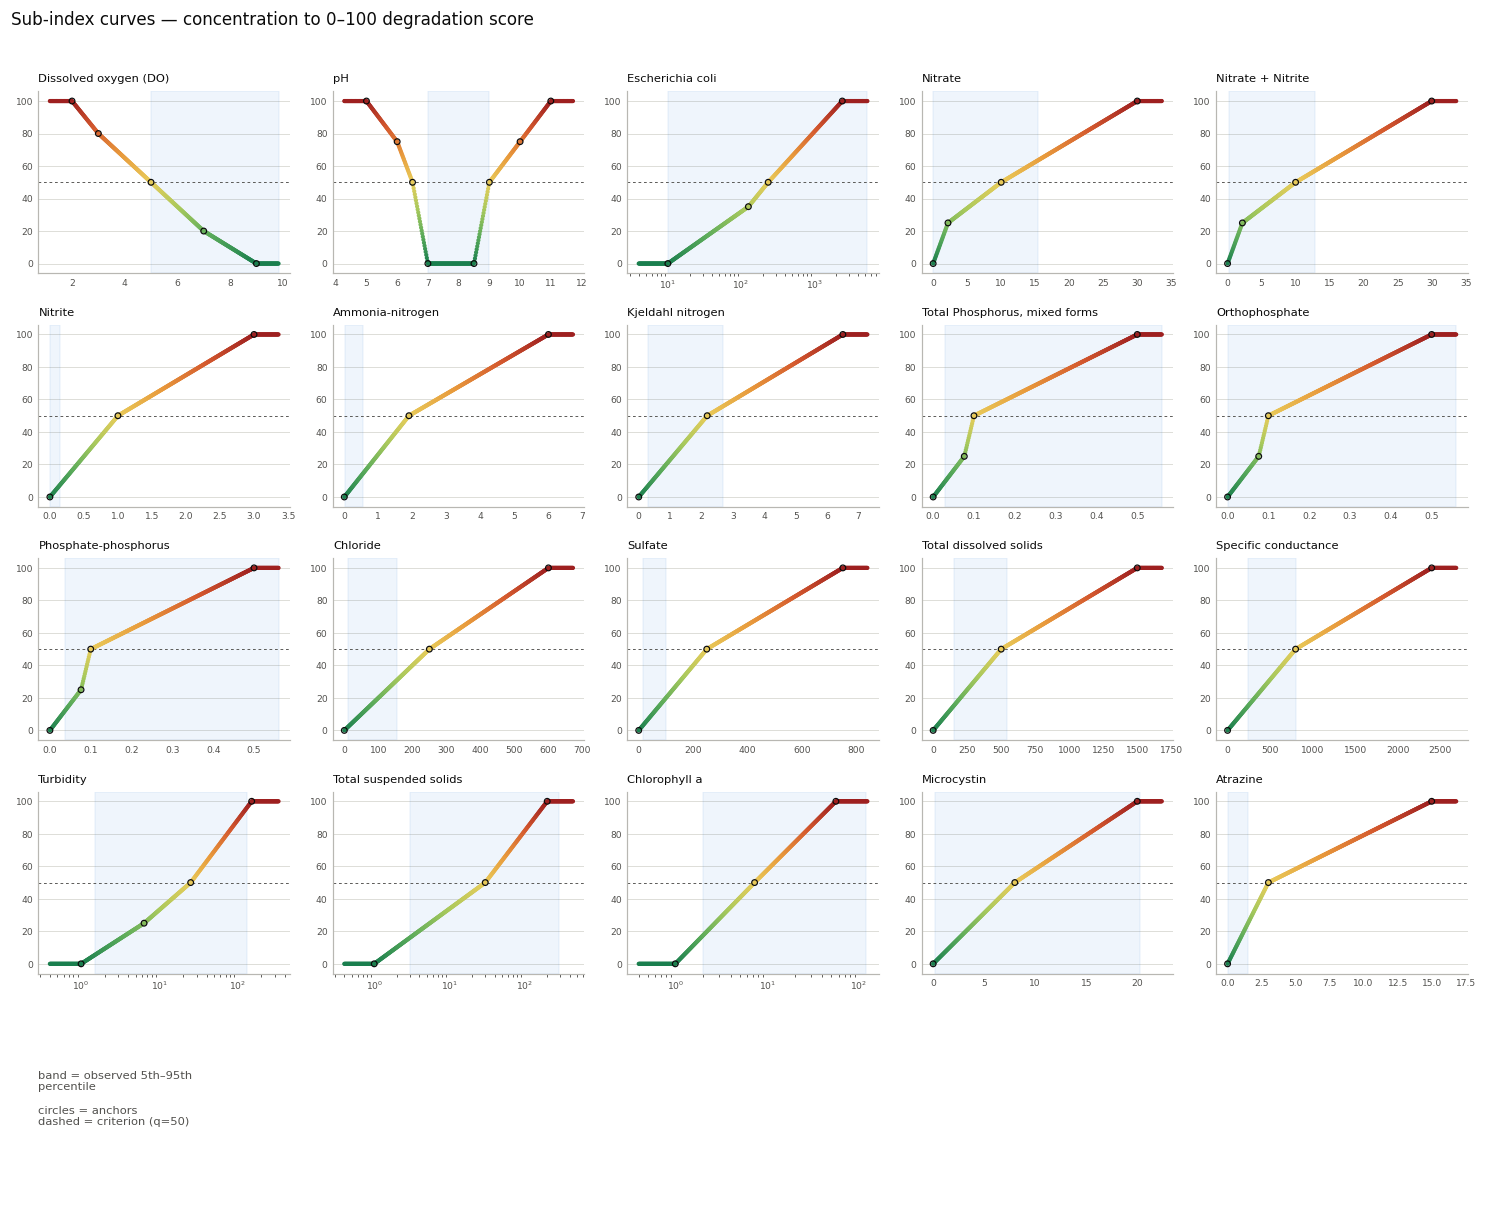

In [6]:
def subindex(values: pd.Series, spec: dict) -> pd.Series:
    """Map raw concentrations onto 0-100 by piecewise-linear interpolation between anchors.

    0 = pristine, 50 = at the regulatory criterion, 100 = severely degraded. Values beyond the
    outermost anchors clamp rather than extrapolate, which is what makes the index robust to
    the censoring and outlier problems the univariate notebook documented (E. coli's implausible
    2,420,000 maximum simply lands on 100, the same as any other gross exceedance).
    """
    x = pd.to_numeric(values, errors="coerce").astype(float)
    xs = np.asarray([a for a, _ in spec["anchors"]], dtype=float)
    ys = np.asarray([q for _, q in spec["anchors"]], dtype=float)
    if spec["scale"] == "log":
        x = np.log10(x.clip(lower=1e-6))
        xs = np.log10(xs)
    out = pd.Series(np.interp(x, xs, ys, left=ys[0], right=ys[-1]), index=values.index)
    return out.where(x.notna())


NCOL = 5
NROW = -(-(len(CURVES) + 1) // NCOL)          # one spare panel for the legend
fig, axes = plt.subplots(NROW, NCOL, figsize=(13.5, 2.25 * NROW))
for ax, (col, spec) in zip(axes.ravel(), CURVES.items()):
    xs = np.asarray([a for a, _ in spec["anchors"]], float)
    if spec["scale"] == "log":
        grid = np.logspace(np.log10(xs.min() * 0.4), np.log10(xs.max() * 2.2), 400)
    else:
        span = xs.max() - xs.min()
        grid = np.linspace(max(0, xs.min() - 0.12 * span), xs.max() + 0.12 * span, 400)
    q = subindex(pd.Series(grid), spec)

    pts = ax.scatter(grid, q, c=q, cmap=QUALITY, vmin=0, vmax=100, s=3, zorder=3)
    ax.scatter(xs, [y for _, y in spec["anchors"]], s=14, facecolor="none",
               edgecolor=INK, linewidth=0.8, zorder=4)
    ax.axhline(50, color=INK_SOFT, lw=0.6, ls=(0, (3, 3)), zorder=2)

    obs = pd.to_numeric(raw[col], errors="coerce").dropna()
    if len(obs):
        lo, hi = obs.quantile([0.05, 0.95])
        ax.axvspan(max(lo, grid.min()), min(hi, grid.max()), color=BLUE, alpha=0.07, zorder=1)

    if spec["scale"] == "log":
        ax.set_xscale("log")
    ax.set_ylim(-6, 106)
    ax.set_title(col.replace("_value", "").replace(", free of pheophytin", ""), fontsize=7.5, loc="left")
    style_axes(ax)
    ax.tick_params(labelsize=6)

for ax in axes.ravel()[len(CURVES):]:
    ax.axis("off")
axes.ravel()[len(CURVES)].text(
    0.0, 0.75,
    "band = observed 5th–95th\npercentile\n\ncircles = anchors\ndashed = criterion (q=50)",
    fontsize=7.5, color=INK_SOFT, va="top")

fig.suptitle("Sub-index curves — concentration to 0–100 degradation score", x=0.008, ha="left", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(OUT_DIR / "wqi_subindex_curves.png", bbox_inches="tight")
plt.show()

In [7]:
Q = pd.DataFrame({c: subindex(raw[c], spec) for c, spec in CURVES.items()})
Q.columns = [c.replace("_value", "") for c in Q.columns]

summary = pd.DataFrame({
    "n": Q.notna().sum(),
    "median_q": Q.median().round(1),
    "p90_q": Q.quantile(0.90).round(1),
    "% over criterion": (100 * (Q > 50).sum() / Q.notna().sum()).round(1),
}).sort_values("% over criterion", ascending=False)
summary["source"] = [CURVES[c + "_value"]["source"] for c in summary.index]
summary

,n,median_q,p90_q,% over criterion,source
Phosphate-phosphorus,8636,57.5,100,70.5,as TP
"Chlorophyll a, free of pheophytin",8661,57.7,100,59.8,Carlson trophic boundaries: 7.3 µg/L meso→eutr...
"Total Phosphorus, mixed forms",5886,53.9,96.2,59.2,Ecoregion VI TP reference 76.25 µg/L; 0.10 mg/...
Orthophosphate,22204,50,98.8,44.7,"as TP — ortho-P is a subset of TP, so this is ..."
Escherichia coli,15898,40.7,100,42.4,IAC 567—61.3 Class A1: 126 geometric mean / 23...
Total suspended solids,14525,43.3,92.4,38.3,30 mg/L — no numeric federal criterion; standa...
Turbidity,21156,38.4,81.8,32.4,Ecoregion VI turbidity reference 6.36 NTU; 25 ...
Microcystin,3058,7.9,52.8,10.9,EPA 2019 recreational criterion 8 µg/L; WHO hi...
Kjeldahl nitrogen,13184,20.2,48.2,9.2,Ecoregion VI TN reference 2.18 mg/L (no regula...
Nitrate + Nitrite,4659,28.2,48.4,8.2,EPA MCL 10 mg/L as N; Ecoregion VI TN referenc...


This table is already a result. The share of samples exceeding their criterion runs from
**the phosphorus species and chlorophyll-a at 59–71%** down to **nitrite, sulfate and ammonia
below 1%** —
which is the correct picture of Iowa surface water. The nutrient and clarity parameters are the
binding constraints; the classical sanitary parameters (pH, DO, nitrite, ammonia) are almost
always fine. An index dominated by DO and pH, as NSF's weighting would make it, would report
that Iowa's water is excellent.

## 5. Grouping — the answer to redundancy

The 20 parameters collapse into **eight pollution groups**. Within a group the sub-index is the
**maximum** across whichever members were measured — the worst-case reading of that kind of
degradation. Between groups, weights apply.

Taking the maximum within a group, rather than the mean, does two jobs at once. It removes the
double-counting (a sample measuring nitrate *and* nitrate+nitrite *and* TKN contributes one
nitrogen score, not three), and it keeps the worst-case semantics that make the index safe:
nitrate at the MCL with ammonia clean is still a nitrogen problem.

### Weights

There is no objective source for these — every published index makes the same judgement call,
and NSF's came from polling 142 experts. Ours follow the same severity logic NSF used, adjusted
for what this table measures and for Iowa's actual impairment profile:

| Group | Weight | Members | Rationale |
|---|---|---|---|
| `pathogen` | **0.20** | E. coli | Direct acute human-health risk; the leading cause of Iowa recreational-use impairment. NSF gave fecal coliform 0.16, the second-highest weight. |
| `oxygen` | **0.18** | DO | The keystone aquatic-life variable; NSF's highest weight at 0.17. |
| `nitrogen` | **0.15** | nitrate, nitrite, NO₃+NO₂, ammonia, TKN | Health-based (nitrate MCL) *and* ecological; Iowa's signature water-quality problem and the driver of the Gulf hypoxic zone. |
| `phosphorus` | **0.12** | TP, orthophosphate, phosphate-P | The limiting nutrient for freshwater eutrophication. |
| `clarity` | **0.10** | turbidity, TSS | Habitat smothering and light limitation; NSF gave turbidity 0.08. |
| `algal_toxics` | **0.10** | chlorophyll-a, microcystin, atrazine | Bloom biomass, cyanotoxin, and the herbicide with an MCL. Low coverage but high consequence. |
| `acidity` | **0.10** | pH | NSF gave pH 0.11. |
| `salinity` | **0.05** | chloride, sulfate, TDS, specific conductance | Mostly *secondary* (aesthetic) standards; genuine but least severe. NSF gave total solids 0.07. |

Weights sum to 1.00 and are **renormalised over the groups a sample actually measured**, which
is what lets one formula serve rows carrying three measurements and rows carrying seventeen.
Section 7.2 perturbs them to show how much the answer depends on them.

In [8]:
GROUPS = {
    "pathogen":     ["Escherichia coli"],
    "oxygen":       ["Dissolved oxygen (DO)"],
    "nitrogen":     ["Nitrate", "Nitrate + Nitrite", "Nitrite", "Ammonia-nitrogen", "Kjeldahl nitrogen"],
    "phosphorus":   ["Total Phosphorus, mixed forms", "Orthophosphate", "Phosphate-phosphorus"],
    "clarity":      ["Turbidity", "Total suspended solids"],
    "algal_toxics": ["Chlorophyll a, free of pheophytin", "Microcystin", "Atrazine"],
    "acidity":      ["pH"],
    "salinity":     ["Chloride", "Sulfate", "Total dissolved solids", "Specific conductance"],
}
WEIGHTS = pd.Series({
    "pathogen": 0.20, "oxygen": 0.18, "nitrogen": 0.15, "phosphorus": 0.12,
    "clarity": 0.10, "algal_toxics": 0.10, "acidity": 0.10, "salinity": 0.05,
})
assert abs(WEIGHTS.sum() - 1) < 1e-9
assert sorted(c for m in GROUPS.values() for c in m) == sorted(Q.columns)

G = pd.DataFrame({g: Q[members].max(axis=1) for g, members in GROUPS.items()})
present = G.notna()
n_groups = present.sum(axis=1)
weight_cov = present.mul(WEIGHTS).sum(axis=1)

grp = pd.DataFrame({
    "weight": WEIGHTS,
    "n_members": [len(m) for m in GROUPS.values()],
    "coverage_%": (100 * present.mean()).round(1),
    "median_q": G.median().round(1),
    "p90_q": G.quantile(0.90).round(1),
    "% over criterion": (100 * (G > 50).sum() / present.sum()).round(1),
})
grp

,weight,n_members,coverage_%,median_q,p90_q,% over criterion
pathogen,0.2,1,32.9,40.7,100,42.4
oxygen,0.18,1,66,1.9,35,4.1
nitrogen,0.15,5,54.1,22.9,50,9.8
phosphorus,0.12,3,56.1,56.2,100,59.3
clarity,0.1,2,49.7,43,89.2,38.3
algal_toxics,0.1,3,26.5,44.9,100,43.2
acidity,0.1,1,67.1,0,50,4.6
salinity,0.05,4,74.3,29.3,44,5.4


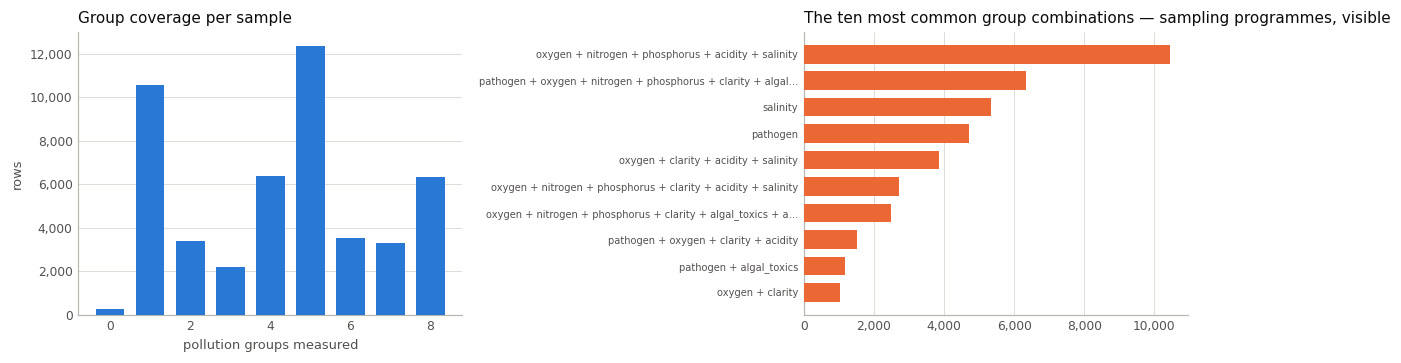

oxygen + nitrogen + phosphorus + acidity + salinity                                        10438
pathogen + oxygen + nitrogen + phosphorus + clarity + algal_toxics + acidity + salinity     6331
salinity                                                                                    5344
pathogen                                                                                    4716
oxygen + clarity + acidity + salinity                                                       3858
oxygen + nitrogen + phosphorus + clarity + acidity + salinity                               2710


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

ax = axes[0]
counts = n_groups.value_counts().sort_index()
ax.bar(counts.index, counts.values, color=BLUE, width=0.72, zorder=3)
ax.set_xlabel("pollution groups measured"); ax.set_ylabel("rows")
ax.set_title("Group coverage per sample", loc="left")
style_axes(ax); thousands(ax)

ax = axes[1]
combos = present.apply(lambda r: " + ".join(present.columns[r.values]) or "(none)", axis=1)
top = combos.value_counts().head(10)[::-1]
ax.barh(range(len(top)), top.values, color=ORANGE, height=0.7, zorder=3)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([t if len(t) < 62 else t[:59] + "…" for t in top.index], fontsize=6.5)
ax.set_title("The ten most common group combinations — sampling programmes, visible", loc="left")
style_axes(ax, axis="x"); thousands(ax, axis="x")

fig.tight_layout()
plt.show()

print(combos.value_counts().head(6).to_string())

## 6. The minimum-data rule

A WQI computed from one group is not a water quality index — it is that one measurement,
rescaled. Something has to separate the samples that support a composite score from the ones
that do not.

Two conditions, both required:

1. **≥ 3 of the 8 groups measured** — a composite needs at least three independent views.
2. **≥ 0.50 of total index weight covered** — three *low-weight* groups (say salinity, acidity
   and clarity, together 0.25) do not constitute a picture of water quality, however many of
   them there are.

Rows failing either test get `WQI = NaN` rather than a misleadingly precise number. The two
companion columns record what each surviving row was built from.

Two things worth noting once the rule is applied, both visible in the output below. The
group-count condition turns out to be **entirely non-binding** — no combination of exactly three
groups reaches 0.50 weight, so the weight condition does all the work and every scored sample
carries at least four groups. And the weight condition does *not* guarantee a heavyweight group:
about 5% of scored samples carry neither `pathogen` nor `oxygen`, reaching 0.50 through
nitrogen + phosphorus + clarity + acidity instead. That is a nutrient-panel view of water
quality, and it is a real limitation of scoring across incompatible sampling programmes.

In [10]:
MIN_GROUPS, MIN_WEIGHT = 3, 0.50
eligible = (n_groups >= MIN_GROUPS) & (weight_cov >= MIN_WEIGHT)

rule_scan = pd.DataFrame([
    {"min_groups": g, "min_weight": w,
     "rows": int(((n_groups >= g) & (weight_cov >= w)).sum()),
     "rows_%": round(100 * ((n_groups >= g) & (weight_cov >= w)).mean(), 1),
     "stations": raw.loc[(n_groups >= g) & (weight_cov >= w), "MonitoringLocationIdentifier"].nunique()}
    for g in (1, 2, 3, 4, 5) for w in (0.0, 0.3, 0.5, 0.7)
]).pivot(index="min_groups", columns="min_weight", values=["rows_%", "stations"])
print("Eligibility surface — % of rows scored (left) and stations retained (right):")
display(rule_scan)

print(f"\nadopted rule: n_groups >= {MIN_GROUPS} and weight_coverage >= {MIN_WEIGHT}")
print(f"  scored rows : {eligible.sum():,} of {len(raw):,}  ({100*eligible.mean():.1f}%)")
print(f"  stations    : {raw.loc[eligible, 'MonitoringLocationIdentifier'].nunique():,} "
      f"of {raw.MonitoringLocationIdentifier.nunique():,}")
print(f"  date range  : {raw.loc[eligible, 'ActivityStartDateTime'].min():%Y-%m-%d} → "
      f"{raw.loc[eligible, 'ActivityStartDateTime'].max():%Y-%m-%d}")
print(f"  median groups per scored row: {n_groups[eligible].median():.0f}   "
      f"median weight coverage: {weight_cov[eligible].median():.2f}")
print(f"  scored rows with exactly {MIN_GROUPS} groups: {(eligible & (n_groups == MIN_GROUPS)).sum():,}")
no_heavy = eligible & ~present["pathogen"] & ~present["oxygen"]
print(f"  scored rows carrying neither pathogen nor oxygen: {no_heavy.sum():,} "
      f"({100 * no_heavy.sum() / eligible.sum():.1f}% of scored)")

Eligibility surface — % of rows scored (left) and stations retained (right):


rows_%                stations              
min_weight    0    0.3  0.5  0.7      0     0.3 0.5 0.7
min_groups                                             
1            99.5   72 56.6 26.2    1,344 1,131 943 435
2            77.5   72 56.6 26.2    1,233 1,131 943 435
3            70.6 69.4 56.6 26.2    1,164 1,130 943 435
4            66.1 66.1 56.6 26.2    1,028 1,028 943 435
5            52.8 52.8 52.8 26.2      789   789 788 435


adopted rule: n_groups >= 3 and weight_coverage >= 0.5
  scored rows : 27,298 of 48,251  (56.6%)
  stations    : 943 of 1,345
  date range  : 2015-01-05 → 2025-12-25
  median groups per scored row: 5   median weight coverage: 0.62
  scored rows with exactly 3 groups: 0
  scored rows carrying neither pathogen nor oxygen: 1,419 (5.2% of scored)


## 7. Aggregation — the choice that matters

Four candidates, all on the eight group sub-indices with renormalised weights. `w` are the
weights of the groups present, `q` their sub-indices, and `SI = 100 − q` the Oregon-direction
("100 = best") form.

| | Formula | Character |
|---|---|---|
| **A · weighted mean** | `Σwq / Σw` | The weighted-arithmetic / NSF form. Vulnerable to eclipsing. |
| **B · mean–max blend** | `(1−λ)·Σwq/Σw + λ·max(q)`, λ = 0.4 | Weighted mean with a worst-parameter term bolted on. |
| **C · Oregon harmonic square mean** | `100 − √(n / Σ 1/SI²)` | Cude's unweighted form, transposed to the 0-worst direction. |
| **D · weighted harmonic square mean** | `100 − √(Σw / Σ(w/SI²))` | C with the group weights restored. |

In [11]:
LAMBDA = 0.40

w_present = present.mul(WEIGHTS)
w_sum = w_present.sum(axis=1)
weighted_mean = (G.fillna(0) * w_present).sum(axis=1) / w_sum.replace(0, np.nan)
worst = G.max(axis=1)
SI = (100 - G).clip(lower=1.0)          # clip keeps 1/SI² finite at total degradation

CANDIDATES = pd.DataFrame({
    "A_weighted_mean":  weighted_mean,
    "B_mean_max_blend": (1 - LAMBDA) * weighted_mean + LAMBDA * worst,
    "C_oregon_hsm":     100 - np.sqrt(n_groups / (1 / SI**2).sum(axis=1)),
    "D_weighted_hsm":   100 - np.sqrt(w_sum / (w_present / SI**2).sum(axis=1)),
}).where(eligible)

print("distribution over the", f"{eligible.sum():,}", "scored rows")
display(CANDIDATES.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(1))

print("\nrank agreement (Spearman)")
display(CANDIDATES.corr(method="spearman").round(3))

distribution over the 27,298 scored rows


,mean,std,min,25%,50%,75%,max
A_weighted_mean,28.2,13.3,0,18.6,27.5,36.9,94.8
B_mean_max_blend,43.8,17,0,31.5,43.3,57.5,96.9
C_oregon_hsm,52,29.7,0,27.8,45.3,75.5,98.9
D_weighted_hsm,51.6,30,0,27,45.1,75.1,98.9



rank agreement (Spearman)


,A_weighted_mean,B_mean_max_blend,C_oregon_hsm,D_weighted_hsm
A_weighted_mean,1,0.939,0.872,0.883
B_mean_max_blend,0.939,1,0.979,0.981
C_oregon_hsm,0.872,0.979,1,0.995
D_weighted_hsm,0.883,0.981,0.995,1


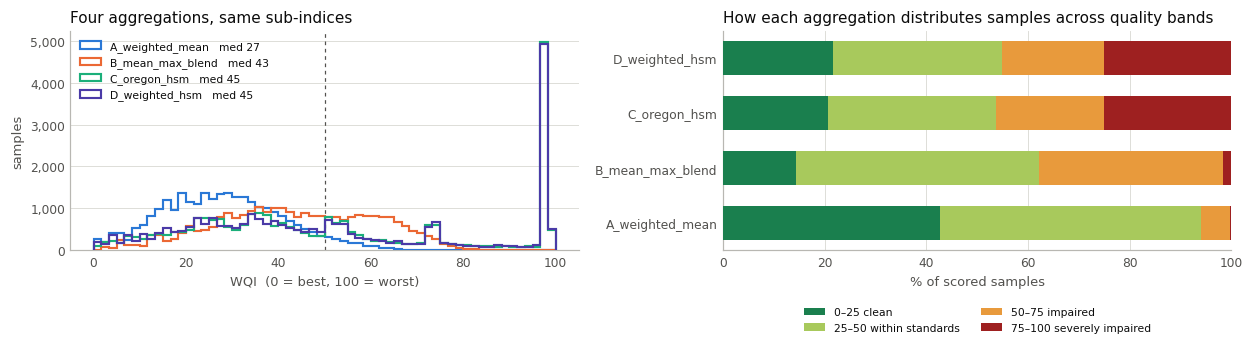

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))

ax = axes[0]
for name, colour in zip(CANDIDATES.columns, [BLUE, ORANGE, AQUA, PURPLE]):
    v = CANDIDATES[name].dropna()
    ax.hist(v, bins=np.linspace(0, 100, 61), histtype="step", lw=1.4, color=colour,
            label=f"{name}   med {v.median():.0f}", zorder=3)
ax.axvline(50, color=INK_SOFT, lw=0.8, ls=(0, (3, 3)), zorder=2)
ax.set_xlabel("WQI  (0 = best, 100 = worst)"); ax.set_ylabel("samples")
ax.set_title("Four aggregations, same sub-indices", loc="left")
ax.legend(fontsize=7)
style_axes(ax); thousands(ax)

ax = axes[1]
bands = [(0, 25, "clean"), (25, 50, "within standards"), (50, 75, "impaired"), (75, 100, "severely impaired")]
bottom = np.zeros(len(CANDIDATES.columns))
for (lo, hi, label), colour in zip(bands, ["#1a7f4e", "#a8c95c", "#e89a3c", "#9e2020"]):
    share = np.array([100 * ((CANDIDATES[c] >= lo) & (CANDIDATES[c] < hi + (hi == 100) * 1e-9)).sum()
                      / CANDIDATES[c].notna().sum() for c in CANDIDATES.columns])
    ax.barh(range(len(CANDIDATES.columns)), share, left=bottom, color=colour, height=0.62,
            label=f"{lo}–{hi} {label}", zorder=3)
    bottom += share
ax.set_yticks(range(len(CANDIDATES.columns)))
ax.set_yticklabels(CANDIDATES.columns, fontsize=8)
ax.set_xlabel("% of scored samples"); ax.set_xlim(0, 100)
ax.set_title("How each aggregation distributes samples across quality bands", loc="left")
ax.legend(fontsize=7, ncol=2, loc="lower center", bbox_to_anchor=(0.5, -0.42))
style_axes(ax, axis="x")

fig.tight_layout()
fig.savefig(OUT_DIR / "wqi_aggregation_comparison.png", bbox_inches="tight")
plt.show()

### 7.1 The eclipsing stress test

The distributions above are suggestive — **A** puts 94% of samples below 50 and only 0.2% above
75, which is implausible for a state where the majority of assessed stream miles are listed as
impaired. But distribution shape is indirect evidence. The direct test is to construct the
failure mode and see which formulas fall for it.

Five synthetic samples, each measuring all eight groups, and three tests they must pass:

- **eclipsing** — seven groups pristine, pathogens catastrophic. Must score **above 50**: no
  index may call a 100× bacterial exceedance acceptable.
- **two severe, six clean** — a second, harder version of the same test.
- **near-miss** — eight varied but mediocre groups, not one of them over its criterion. Must
  score **below 50**.
- **uniformly bad** vs **eclipsing** — the *ordering* test. Eight groups at 80 is worse water
  than one group at 100 and seven pristine, so uniformly-bad must **outscore** eclipsing.
- **pristine** — the floor.

In [13]:
def aggregate_all(g: pd.Series) -> dict:
    """Apply all four aggregations to one complete group-sub-index vector."""
    p = g.notna()
    w = WEIGHTS[p.index][p]
    q = g[p]
    si = (100 - q).clip(lower=1.0)
    wm = float((w * q).sum() / w.sum())
    return {
        "A_weighted_mean":  wm,
        "B_mean_max_blend": (1 - LAMBDA) * wm + LAMBDA * float(q.max()),
        "C_oregon_hsm":     100 - float(np.sqrt(len(q) / (1 / si**2).sum())),
        "D_weighted_hsm":   100 - float(np.sqrt(w.sum() / (w / si**2).sum())),
    }


scenarios = {
    "eclipsing (7 pristine, pathogen 100)":
        pd.Series({g: (100.0 if g == "pathogen" else 3.0) for g in WEIGHTS.index}),
    "two severe, six clean":
        pd.Series(dict(zip(WEIGHTS.index, [95.0, 90, 5, 4, 3, 3, 2, 2]))),
    "near-miss (varied, none over criterion)":
        pd.Series(dict(zip(WEIGHTS.index, [48.0, 45, 42, 40, 38, 35, 33, 30]))),
    "uniformly bad (all 8 at 80)":
        pd.Series({g: 80.0 for g in WEIGHTS.index}),
    "pristine (all 8 at 3)":
        pd.Series({g: 3.0 for g in WEIGHTS.index}),
}
stress = pd.DataFrame({k: aggregate_all(v) for k, v in scenarios.items()}).T.round(1)
display(stress)

verdict = pd.DataFrame({
    "eclipsing > 50":          stress.loc["eclipsing (7 pristine, pathogen 100)"] > 50,
    "two-severe > 50":         stress.loc["two severe, six clean"] > 50,
    "near-miss < 50":          stress.loc["near-miss (varied, none over criterion)"] < 50,
    "uniformly-bad > eclipsing": (stress.loc["uniformly bad (all 8 at 80)"]
                                  > stress.loc["eclipsing (7 pristine, pathogen 100)"]),
}).T
verdict.loc["ALL PASS"] = verdict.all()
verdict

,A_weighted_mean,B_mean_max_blend,C_oregon_hsm,D_weighted_hsm
"eclipsing (7 pristine, pathogen 100)",22.4,53.4,97.2,97.8
"two severe, six clean",37.3,60.4,87.4,89.9
"near-miss (varied, none over criterion)",40.9,43.7,39.7,41.6
uniformly bad (all 8 at 80),80,80,80,80
pristine (all 8 at 3),3,3,3,3


,A_weighted_mean,B_mean_max_blend,C_oregon_hsm,D_weighted_hsm
eclipsing > 50,False,True,True,True
two-severe > 50,False,True,True,True
near-miss < 50,True,True,True,True
uniformly-bad > eclipsing,True,True,False,False
ALL PASS,False,True,False,False


The stress test decides it, and **B is the only candidate that passes all four checks.**

- **A fails both eclipsing tests.** It scores the eclipsing sample at **22.4** and the
  two-severe sample at **37.3** — both comfortably "clean" — while the water carries 100× the
  recreational E. coli standard. This is the textbook eclipsing failure and it disqualifies the
  plain weighted-arithmetic form that NSF and the Horton/Brown index both use.
- **C and D fail the ordering test.** They score the eclipsing sample at **97.2 / 97.8**, above
  the uniformly-bad sample's 80. One severe exceedance out-ranking eight severe exceedances is
  not defensible. The reciprocal-square term is simply too aggressive once a sub-index reaches
  100, which our clamped curves guarantee will happen.
- **The near-miss test discriminates nothing** — all four land between 39.7 and 43.7. This is
  worth stating rather than quietly dropping: the harmonic square mean is bounded by its own
  worst component, so it cannot manufacture classical *ambiguity*, and neither can a weighted
  mean. Ambiguity is a failure mode of *multiplicative* aggregation (Bhargava's geometric mean),
  which is not among the candidates. The test was run and it came back empty.
- **B** scores eclipsing at **53.4** and two-severe at **60.4** (over the line, correctly),
  near-miss at **43.7** (under the line, correctly), and keeps uniformly-bad at 80 above both
  eclipsing cases.

The distributional evidence points the same way. **A** puts 94% of scored samples below 50 and
0.2% above 75, which is not a credible picture of a state where most assessed stream miles are
listed as impaired; **C** and **D** push a quarter of all samples past 75, turning the index into
a report on whichever single parameter hit the clamp.

**Selected: B — the weighted mean–max blend at λ = 0.40.**

$$
\mathrm{WQI} \;=\; 0.6 \cdot \frac{\sum_{g \in P} w_g\, q_g}{\sum_{g \in P} w_g} \;+\; 0.4 \cdot \max_{g \in P} q_g
$$

where $P$ is the set of pollution groups measured on that sample, $q_g$ the group sub-index and
$w_g$ its weight. The mean term keeps the index a genuine composite; the max term is the
Oregon-derived guarantee that a single severe exceedance cannot be averaged away.

In [14]:
lam_scan = pd.DataFrame({
    f"λ={lam:.1f}": {k: round((1 - lam) * aggregate_all(v)["A_weighted_mean"]
                              + lam * float(v.max()), 1) for k, v in scenarios.items()}
    for lam in (0.0, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0)
})
print("λ sweep on the stress scenarios — λ must put eclipsing above 50 and ambiguity below it:")
display(lam_scan)

lam_real = pd.DataFrame({f"λ={lam:.1f}": ((1 - lam) * weighted_mean + lam * worst)[eligible]
                         for lam in (0.0, 0.2, 0.4, 0.6, 0.8, 1.0)})
print("\nand on the real data — median / % scored above 50:")
display(pd.DataFrame({"median": lam_real.median().round(1),
                      "% over 50": (100 * (lam_real > 50).mean()).round(1),
                      "ρ vs λ=0.4": lam_real.corrwith(lam_real["λ=0.4"], method="spearman").round(3)}))

λ sweep on the stress scenarios — λ must put eclipsing above 50 and ambiguity below it:


,λ=0.0,λ=0.2,λ=0.3,λ=0.4,λ=0.5,λ=0.7,λ=1.0
"eclipsing (7 pristine, pathogen 100)",22.4,37.9,45.7,53.4,61.2,76.7,100
"two severe, six clean",37.3,48.9,54.6,60.4,66.2,77.7,95
"near-miss (varied, none over criterion)",40.9,42.3,43,43.7,44.5,45.9,48
uniformly bad (all 8 at 80),80,80,80,80,80,80,80
pristine (all 8 at 3),3,3,3,3,3,3,3



and on the real data — median / % scored above 50:


,median,% over 50,ρ vs λ=0.4
λ=0.0,27.5,5.9,0.939
λ=0.2,35.8,18.6,0.989
λ=0.4,43.3,37.8,1
λ=0.6,51.4,52.2,0.994
λ=0.8,58.7,63.9,0.984
λ=1.0,65.6,70.4,0.963


λ = 0.4 is the smallest value that clears the eclipsing scenario, and the index is not
knife-edge sensitive to it — every λ from 0.2 to 0.8 ranks samples at ρ > 0.94 against λ = 0.4.
The choice moves the *level* of the index far more than it moves the *ordering*.

### 7.2 Weight sensitivity

In [15]:
rng = np.random.default_rng(20260805)

def wqi_from_weights(w: pd.Series, lam: float = LAMBDA) -> pd.Series:
    wp = present.mul(w)
    ws = wp.sum(axis=1)
    wm = (G.fillna(0) * wp).sum(axis=1) / ws.replace(0, np.nan)
    return ((1 - lam) * wm + lam * worst).where(eligible)


baseline = wqi_from_weights(WEIGHTS)

perturbations = {"equal weights (0.125 each)": pd.Series(0.125, index=WEIGHTS.index),
                 "NSF-like (DO & pathogen heavy)": pd.Series(
                     {"oxygen": .24, "pathogen": .22, "acidity": .15, "clarity": .11,
                      "nitrogen": .10, "phosphorus": .08, "salinity": .06, "algal_toxics": .04})}
for i in range(30):
    jitter = WEIGHTS * (1 + rng.uniform(-0.5, 0.5, len(WEIGHTS)))
    perturbations[f"random ±50% #{i}"] = jitter / jitter.sum()

rows = []
for name, w in perturbations.items():
    v = wqi_from_weights(w / w.sum())
    rows.append({"scheme": name, "median": v.median(),
                 "% over 50": 100 * (v > 50).sum() / v.notna().sum(),
                 "ρ vs adopted": v.corr(baseline, method="spearman"),
                 "median |Δ|": (v - baseline).abs().median()})
sens = pd.DataFrame(rows)

print(sens.head(2).round(3).to_string(index=False))
print("\n30 random ±50% weight perturbations:")
print(sens.tail(30)[["median", "% over 50", "ρ vs adopted", "median |Δ|"]].describe()
      .loc[["min", "50%", "max"]].round(3).to_string())

                        scheme  median  % over 50  ρ vs adopted  median |Δ|
    equal weights (0.125 each)   43.74      38.17         0.994       1.178
NSF-like (DO & pathogen heavy)   41.58      33.61         0.994       2.173

30 random ±50% weight perturbations:
     median  % over 50  ρ vs adopted  median |Δ|
min   41.68      33.59         0.992        0.39
50%   43.38      37.84         0.996       1.143
max   46.41      43.61         0.999       3.216


Under random ±50% jitter on every weight, sample rankings hold at Spearman **ρ = 0.992–0.999**
and the median sample moves by **about one index point** (worst case 3.2). Even *equal weights*
and a deliberately NSF-shaped scheme — which triples oxygen's weight relative to phosphorus —
rank samples at ρ = 0.994 against the adopted scheme.

The weights move the index's **level** rather than its **ordering**, which is the useful
conclusion: the most subjective ingredient in the construction is the one the results depend on
least.

The 50-point line should still be read as a soft boundary. Under the same jitter the share of
samples scoring above 50 ranges from **34% to 44%** — a ten-point spread — even while almost no
sample changes rank relative to any other. Use the WQI to *order* samples with confidence; use
the 50 threshold as a guide, not a verdict.

### 7.3 Sensitivity: what if temperature were included?

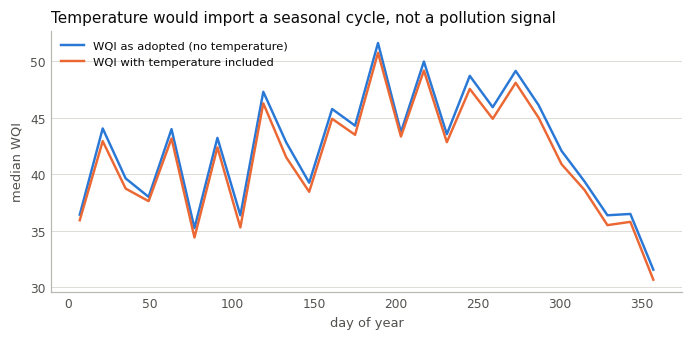

ρ(with_temp, adopted) = 0.9996
samples where the thermal group is the worst group: 123 (0.45%)
samples exceeding the 32 °C criterion: 30


In [16]:
temp_spec = dict(scale="linear", anchors=[(20, 0), (29, 25), (32, 50), (35, 100)],
                 source="IAC 567—61.3 Class B(WW-1) maximum 32 °C")
q_temp = subindex(raw["Temperature, water_value"], temp_spec)

G_t = G.assign(thermal=q_temp)
W_t = (pd.concat([WEIGHTS, pd.Series({"thermal": 0.05})]))
W_t = W_t / W_t.sum()
pres_t = G_t.notna()
wp_t = pres_t.mul(W_t)
wm_t = (G_t.fillna(0) * wp_t).sum(axis=1) / wp_t.sum(axis=1).replace(0, np.nan)
with_temp = ((1 - LAMBDA) * wm_t + LAMBDA * G_t.max(axis=1)).where(eligible)

doy = raw["ActivityStartDateTime"].dt.dayofyear
fig, ax = plt.subplots(figsize=(6.4, 3.2))
for series, name, colour in [(baseline, "WQI as adopted (no temperature)", BLUE),
                             (with_temp, "WQI with temperature included", ORANGE)]:
    m = series.groupby(pd.cut(doy, np.arange(0, 380, 14))).median()
    ax.plot([iv.mid for iv in m.index], m.values, color=colour, lw=1.6, label=name, zorder=3)
ax.set_xlabel("day of year"); ax.set_ylabel("median WQI")
ax.set_title("Temperature would import a seasonal cycle, not a pollution signal", loc="left")
ax.legend(fontsize=7.5)
style_axes(ax)
fig.tight_layout()
plt.show()

print(f"ρ(with_temp, adopted) = {with_temp.corr(baseline, method='spearman'):.4f}")
thermal_worst = G_t[eligible].idxmax(axis=1) == "thermal"
print(f"samples where the thermal group is the worst group: {thermal_worst.sum():,} "
      f"({100*thermal_worst.mean():.2f}%)")
print(f"samples exceeding the 32 °C criterion: {(pd.to_numeric(raw['Temperature, water_value'], errors='coerce') > 32).sum():,}")

Including temperature changes almost nothing at the sample level (ρ ≈ 1.00) because Iowa streams
essentially never breach the 32 °C criterion — but it does add a visible summer bump to the
seasonal profile, which is exactly the artefact the exclusion was meant to avoid. **Excluded,
confirmed.**

## 8. Validation

The index was built from thresholds, not fitted to anything, so it can be checked against
independent evidence. Four checks:

1. **CCME agreement** — an entirely different algorithm, computed per station over time
2. **Impairment listings** — does the index agree with Iowa's 303(d) determinations?
3. **Land cover** — does it reproduce the row-crop → nutrient gradient the bivariate notebook found?
4. **Hydrology and season** — does it behave like water quality is known to behave?

### 8.1 Independent benchmark: CCME WQI per station

agreement rises with how well a station is sampled:
  stations with >= 4 scored samples:  587   Spearman +0.509
  stations with >=10 scored samples:  489   Spearman +0.540
  stations with >=20 scored samples:  345   Spearman +0.624
  stations with >=40 scored samples:  154   Spearman +0.493


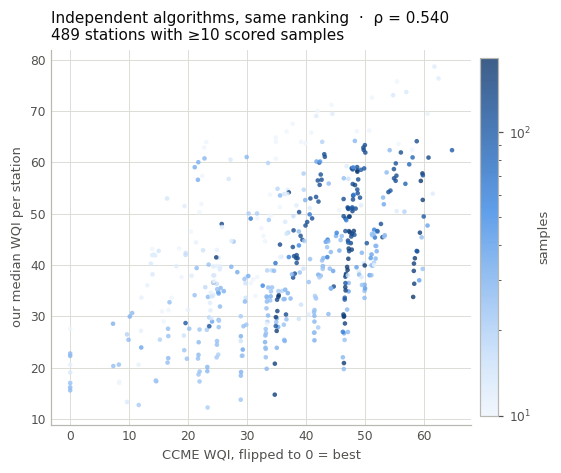

In [17]:
def ccme_wqi(sub: pd.DataFrame) -> float:
    """CCME WQI 1.0 over a station's samples, using q>50 as the objective failure test.

    F1 scope     = % of variables that fail at least once
    F2 frequency = % of individual tests that fail
    F3 amplitude = nse / (0.01·nse + 0.01), nse = Σ excursion / total tests
    WQI = 100 − √(F1²+F2²+F3²)/1.732      (100 = best, so it is flipped to match ours)
    """
    vals = sub.dropna(axis=1, how="all")
    if vals.shape[1] < 4 or len(vals) < 4:
        return np.nan
    tests = vals.notna().sum().sum()
    failed = vals > 50
    f1 = 100 * (failed.any().sum() / vals.shape[1])
    f2 = 100 * (failed.sum().sum() / tests)
    # excursion, expressed against the q=50 objective
    exc = ((vals[failed] / 50) - 1).sum().sum()
    nse = exc / tests
    f3 = nse / (0.01 * nse + 0.01)
    return 100 - np.sqrt(f1**2 + f2**2 + f3**2) / 1.732


station = raw["MonitoringLocationIdentifier"]
# CCME is run over the same scored rows our index uses, so the comparison isolates the
# algorithm rather than the row selection.
ccme = G[eligible].groupby(station[eligible]).apply(ccme_wqi)
ours = baseline.groupby(station).median()
n_obs = baseline.groupby(station).count()

bench_all = pd.DataFrame({"ccme_100_best": ccme, "our_median_wqi": ours, "n": n_obs}).dropna()
bench_all["ccme_flipped"] = 100 - bench_all["ccme_100_best"]

print("agreement rises with how well a station is sampled:")
for k in (4, 10, 20, 40):
    b = bench_all[bench_all["n"] >= k]
    print(f"  stations with >={k:2d} scored samples: {len(b):4d}   "
          f"Spearman {b['our_median_wqi'].corr(b['ccme_flipped'], method='spearman'):+.3f}")

bench = bench_all[bench_all["n"] >= 10]
rho = bench["our_median_wqi"].corr(bench["ccme_flipped"], method="spearman")

SEQUENTIAL = LinearSegmentedColormap.from_list(
    "wq_seq", ["#eef5fd", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])

fig, ax = plt.subplots(figsize=(5.2, 4.4))
sc = ax.scatter(bench["ccme_flipped"], bench["our_median_wqi"], s=9, c=bench["n"],
                cmap=SEQUENTIAL, norm="log", alpha=0.8, linewidth=0, zorder=3)
ax.set_xlabel("CCME WQI, flipped to 0 = best")
ax.set_ylabel("our median WQI per station")
ax.set_title(f"Independent algorithms, same ranking  ·  ρ = {rho:.3f}\n"
             f"{len(bench):,} stations with ≥10 scored samples", loc="left")
fig.colorbar(sc, ax=ax, fraction=0.04, pad=0.02, label="samples")
style_axes(ax, axis="both")
fig.tight_layout()
fig.savefig(OUT_DIR / "wqi_ccme_benchmark.png", bbox_inches="tight")
plt.show()

**ρ ≈ 0.54** — moderate agreement, and it is worth being precise about what that does and does
not establish.

CCME shares almost no machinery with our index: no weights, no rating curves, no group
structure, and it aggregates over *time* rather than within a sample. It shares only the
threshold table. Two constructions that different agreeing at ρ ≈ 0.5 is real corroboration —
the ranking is not an artefact of our particular algebra — but it is a long way from
redundancy, and it would be wrong to present it as strong validation.

The disagreement is itself informative. CCME's **F1** term is the percentage of *variables* that
fail at least once, so a station measuring four parameters and failing one scores F1 = 25 while
a station measuring eight and failing two scores the same — the term is partly a function of the
sampling panel rather than the water. Our index has no scope term at all.

Agreement also rises with sampling effort — **0.51** at ≥4 scored samples, **0.62** at ≥20 —
which is consistent with part of the gap being estimation noise in both indices rather than
genuine disagreement about which waters are worse. It then falls back to **0.49** at ≥40, but
that bin holds only 154 stations and they are the most intensively monitored ones, so the drop
is as likely to be restriction of range as anything about the indices. The honest reading is
that agreement is moderate and roughly flat around 0.5–0.6, not that it improves without
limit.

### 8.2 Does the index agree with Iowa's own impairment listings?

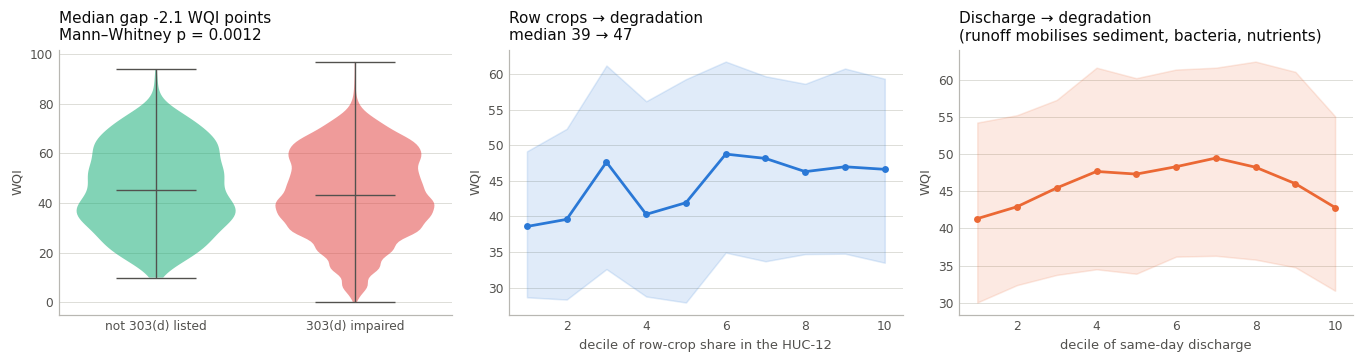

In [18]:
imp = raw["npdes__any_impaired"]
tbl = pd.DataFrame({"wqi": baseline, "impaired": imp}).dropna()

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))

ax = axes[0]
groups = [tbl.loc[tbl.impaired == v, "wqi"] for v in sorted(tbl.impaired.unique())]
parts = ax.violinplot(groups, showmedians=True, widths=0.8)
for pc, colour in zip(parts["bodies"], [AQUA, RED]):
    pc.set_facecolor(colour); pc.set_alpha(0.55); pc.set_edgecolor("none")
for key in ("cbars", "cmins", "cmaxes", "cmedians"):
    parts[key].set_color(INK_SOFT); parts[key].set_linewidth(0.9)
ax.set_xticks([1, 2]); ax.set_xticklabels(["not 303(d) listed", "303(d) impaired"], fontsize=8)
ax.set_ylabel("WQI")
u = stats.mannwhitneyu(groups[0], groups[1])
delta = groups[1].median() - groups[0].median()
ax.set_title(f"Median gap {delta:+.1f} WQI points\nMann–Whitney p = {u.pvalue:.2g}", loc="left")
style_axes(ax)

ax = axes[1]
corn = pd.to_numeric(raw["pct_row_crops"], errors="coerce")
dec = pd.qcut(corn, 10, labels=False, duplicates="drop")
m = baseline.groupby(dec).median()
lo = baseline.groupby(dec).quantile(0.25); hi = baseline.groupby(dec).quantile(0.75)
ax.fill_between(m.index + 1, lo.values, hi.values, color=BLUE, alpha=0.14, zorder=2)
ax.plot(m.index + 1, m.values, color=BLUE, lw=1.8, marker="o", ms=3.5, zorder=3)
ax.set_xlabel("decile of row-crop share in the HUC-12"); ax.set_ylabel("WQI")
ax.set_title(f"Row crops → degradation\nmedian {m.iloc[0]:.0f} → {m.iloc[-1]:.0f}", loc="left")
style_axes(ax)

ax = axes[2]
q = pd.to_numeric(raw["streamflow_discharge_cfs"], errors="coerce")
dec = pd.qcut(q, 10, labels=False, duplicates="drop")
m = baseline.groupby(dec).median()
lo = baseline.groupby(dec).quantile(0.25); hi = baseline.groupby(dec).quantile(0.75)
ax.fill_between(m.index + 1, lo.values, hi.values, color=ORANGE, alpha=0.14, zorder=2)
ax.plot(m.index + 1, m.values, color=ORANGE, lw=1.8, marker="o", ms=3.5, zorder=3)
ax.set_xlabel("decile of same-day discharge"); ax.set_ylabel("WQI")
ax.set_title("Discharge → degradation\n(runoff mobilises sediment, bacteria, nutrients)", loc="left")
style_axes(ax)

fig.tight_layout()
fig.savefig(OUT_DIR / "wqi_validation.png", bbox_inches="tight")
plt.show()

### 8.3 Season, space, and which group drives the index

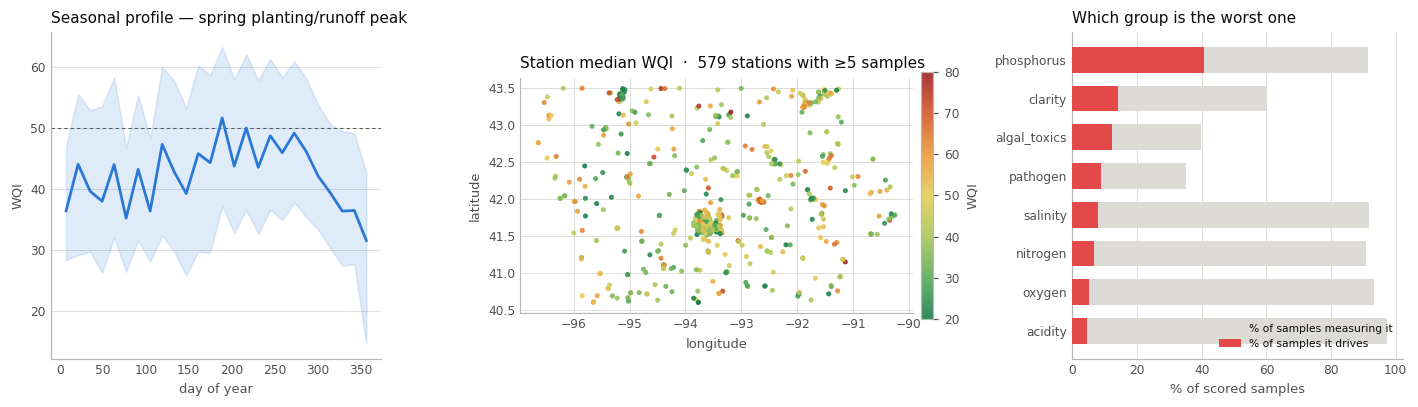

how often each group is the worst one, given that it was measured:
              drives_%  measured_%  drive_rate
phosphorus        40.8        91.5        0.45
algal_toxics      12.1        39.8         0.3
pathogen           8.9          35        0.25
clarity             14        60.2        0.23
salinity           7.9        91.8        0.09
nitrogen           6.8        90.7        0.07
acidity            4.4        97.3        0.05
oxygen             5.1        93.4        0.05

Spearman(WQI, WQI_weight_coverage) = +0.239
Spearman(WQI, WQI_n_groups)        = +0.250


In [19]:
fig = plt.figure(figsize=(13, 3.8))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.25, 1])

ax = fig.add_subplot(gs[0])
doy = raw["ActivityStartDateTime"].dt.dayofyear
bins = pd.cut(doy, np.arange(0, 380, 14))
m = baseline.groupby(bins).median(); lo = baseline.groupby(bins).quantile(.25); hi = baseline.groupby(bins).quantile(.75)
x = [iv.mid for iv in m.index]
ax.fill_between(x, lo.values, hi.values, color=BLUE, alpha=0.14, zorder=2)
ax.plot(x, m.values, color=BLUE, lw=1.8, zorder=3)
ax.axhline(50, color=INK_SOFT, lw=0.7, ls=(0, (3, 3)), zorder=1)
ax.set_xlabel("day of year"); ax.set_ylabel("WQI")
ax.set_title("Seasonal profile — spring planting/runoff peak", loc="left")
style_axes(ax)

ax = fig.add_subplot(gs[1])
st = pd.DataFrame({"station": raw["MonitoringLocationIdentifier"], "lat": raw["LatitudeMeasure"],
                   "lon": raw["LongitudeMeasure"], "wqi": baseline}).dropna()
st = st.groupby("station").agg(lat=("lat", "first"), lon=("lon", "first"),
                               wqi=("wqi", "median"), n=("wqi", "size"))
st = st[st["n"] >= 5]
sc = ax.scatter(st["lon"], st["lat"], c=st["wqi"], cmap=QUALITY, vmin=20, vmax=80,
                s=11, linewidth=0, alpha=0.9, zorder=3)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title(f"Station median WQI  ·  {len(st):,} stations with ≥5 samples", loc="left")
ax.set_aspect(1.32)
fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label="WQI")
style_axes(ax, axis="both")

ax = fig.add_subplot(gs[2])
driver = G[eligible].idxmax(axis=1)
share = (100 * driver.value_counts() / len(driver)).sort_values()
avail = (100 * present[eligible].sum() / eligible.sum())[share.index]
ax.barh(range(len(share)), avail.values, color=GRIDLINE, height=0.66, zorder=2, label="% of samples measuring it")
ax.barh(range(len(share)), share.values, color=RED, height=0.66, zorder=3, label="% of samples it drives")
ax.set_yticks(range(len(share))); ax.set_yticklabels(share.index, fontsize=8)
ax.set_xlabel("% of scored samples")
ax.set_title("Which group is the worst one", loc="left")
ax.legend(fontsize=7, loc="lower right")
style_axes(ax, axis="x")

fig.tight_layout()
fig.savefig(OUT_DIR / "wqi_behaviour.png", bbox_inches="tight")
plt.show()

drivers = pd.DataFrame({"drives_%": share.round(1), "measured_%": avail.round(1)})
drivers["drive_rate"] = (drivers["drives_%"] / drivers["measured_%"]).round(2)
print("how often each group is the worst one, given that it was measured:")
print(drivers.sort_values("drive_rate", ascending=False).to_string())
print(f"\nSpearman(WQI, WQI_weight_coverage) = "
      f"{baseline[eligible].corr(weight_cov[eligible], method='spearman'):+.3f}")
print(f"Spearman(WQI, WQI_n_groups)        = "
      f"{baseline[eligible].corr(n_groups[eligible], method='spearman'):+.3f}")

Every check points the same way. The index rises with row-crop share, rises with discharge
(storm runoff mobilises sediment, bacteria and nutrients), peaks in late spring when planting
overlaps with the wettest weeks of the Iowa year, separates 303(d)-listed waters from unlisted
ones, and maps onto the intensively farmed north-central and north-west of the state. None of
that was fitted — it falls out of published thresholds.

The right panel and the table under it are the honest caveat. **Phosphorus is the worst group on
41% of scored samples**, and when it is measured it is the binding constraint 45% of the time —
against 5% for oxygen and 5% for pH, the two groups carrying the largest NSF-style weights.
`algal_toxics` (30%) and `pathogen` (25%) follow.

That is a real finding rather than a bug: Iowa's phosphorus sits above the Ecoregion VI
reference condition on most samples, so the index is in practice a **nutrient-and-clarity index
with bacterial spikes**, which is a fair description of what actually limits Iowa surface water.
But it does mean the index inherits whatever is arguable about the phosphorus anchors — §7.2's
reassurance about weight insensitivity does *not* extend to threshold choices, which move the
index directly.

## 9. Write `WQI` back to `epa-full.csv`

The write is deliberately conservative. The existing 315 columns are read back as **raw
strings** and re-emitted verbatim, so nothing in the file is reformatted, re-rounded or
re-quoted by a pandas round-trip — only three columns are appended. The original is copied to
`epa-full.csv.bak` first, and the new file is written to a temporary path and moved into place
only after it verifies.

In [20]:
WQI = baseline.round(2)

out = pd.DataFrame({
    "WQI": WQI,
    "WQI_n_groups": n_groups.where(eligible).astype("Int64"),
    "WQI_weight_coverage": weight_cov.where(eligible).round(3),
})
print(out.describe().T.round(2).to_string())
print(f"\nnon-null WQI: {out['WQI'].notna().sum():,} / {len(out):,} ({100*out['WQI'].notna().mean():.1f}%)")

bands = pd.cut(out["WQI"], [0, 25, 50, 75, 100], include_lowest=True,
               labels=["0–25 clean", "25–50 within standards", "50–75 impaired", "75–100 severely impaired"])
print("\nband distribution:")
print(bands.value_counts().sort_index().to_frame("samples").assign(
    pct=lambda d: (100 * d["samples"] / d["samples"].sum()).round(1)).to_string())

                       count   mean    std min   25%   50%   75%   max
WQI                 2.73e+04  43.75  17.02   0 31.49 43.34 57.53 96.88
WQI_n_groups        2.73e+04  5.997   1.33   4     5     5     7     8
WQI_weight_coverage 2.73e+04 0.7271 0.1689 0.5   0.6  0.62   0.9     1

non-null WQI: 27,298 / 48,251 (56.6%)

band distribution:
                          samples  pct
WQI                                   
0–25 clean                   3923 14.4
25–50 within standards      13045 47.8
50–75 impaired               9908 36.3
75–100 severely impaired      422  1.5


In [21]:
BACKUP = DATA_PATH.with_suffix(".csv.bak")
TMP = DATA_PATH.with_suffix(".csv.tmp")

# Read every existing column as text so the round-trip cannot alter a single character of it.
verbatim = pd.read_csv(DATA_PATH, dtype=str, keep_default_na=False, na_filter=False, low_memory=False)
assert len(verbatim) == len(out), (len(verbatim), len(out))

for col in ("WQI", "WQI_n_groups", "WQI_weight_coverage"):
    verbatim = verbatim.drop(columns=col, errors="ignore")     # idempotent re-runs

verbatim["WQI"] = out["WQI"].map(lambda v: "" if pd.isna(v) else f"{v:.2f}").values
verbatim["WQI_n_groups"] = out["WQI_n_groups"].map(lambda v: "" if pd.isna(v) else str(int(v))).values
verbatim["WQI_weight_coverage"] = out["WQI_weight_coverage"].map(lambda v: "" if pd.isna(v) else f"{v:.3f}").values

if not BACKUP.exists():
    shutil.copy2(DATA_PATH, BACKUP)
    print(f"backup written: {BACKUP.name}")
else:
    print(f"backup already present: {BACKUP.name} (left untouched)")

verbatim.to_csv(TMP, index=False)

# Verify before replacing: shape, column order, and that the WQI column survived the round-trip.
check = pd.read_csv(TMP, usecols=["MonitoringLocationIdentifier", "WQI", "WQI_n_groups", "WQI_weight_coverage"],
                    low_memory=False)
assert len(check) == len(raw)
assert np.allclose(check["WQI"].dropna().values, out["WQI"].dropna().values, atol=5e-3)
assert list(pd.read_csv(TMP, nrows=0).columns)[-3:] == ["WQI", "WQI_n_groups", "WQI_weight_coverage"]

TMP.replace(DATA_PATH)
print(f"\nwrote {DATA_PATH.relative_to(REPO_ROOT)}  "
      f"({DATA_PATH.stat().st_size / 1e6:.1f} MB, {len(pd.read_csv(DATA_PATH, nrows=0).columns)} columns)")

backup already present: epa-full.csv.bak (left untouched)



wrote data/03c_merge_tertiary/epa-full.csv  (81.3 MB, 318 columns)


In [22]:
# Persist the index definition alongside the EDA outputs so app.py / the training notebooks can
# reproduce it without re-reading this notebook.
definition = {
    "name": "WQI",
    "direction": "0 = best, 100 = worst",
    "criterion_anchor": 50,
    "aggregation": {"method": "weighted mean-max blend", "lambda": LAMBDA,
                    "formula": "(1-λ)·Σwq/Σw + λ·max(q)"},
    "min_data_rule": {"min_groups": MIN_GROUPS, "min_weight_coverage": MIN_WEIGHT},
    "within_group": "max",
    "weights": WEIGHTS.to_dict(),
    "groups": GROUPS,
    "excluded": {"Alkalinity, total": "buffering capacity, not a contaminant",
                 "Hardness, carbonate": "criteria modifier, not a pollutant",
                 "Temperature, water": "seasonal, not a pollution signal (NSF uses ΔT)"},
    "curves": {k: {"scale": v["scale"], "anchors": v["anchors"], "source": v["source"]}
               for k, v in CURVES.items()},
    "coverage": {"scored_rows": int(eligible.sum()), "total_rows": int(len(raw)),
                 "stations": int(raw.loc[eligible, "MonitoringLocationIdentifier"].nunique())},
}
(OUT_DIR / "wqi_definition.json").write_text(json.dumps(definition, indent=2))
print("wrote", (OUT_DIR / "wqi_definition.json").relative_to(REPO_ROOT))

wrote src/04_eda/outputs/wqi_definition.json


---

## 10. Summary

**`WQI` — 0 = best, 100 = worst, one value per (station, timestamp).**

**Construction.** 20 measured parameters → threshold-anchored sub-index curves (q = 0 pristine,
**q = 50 at the regulatory criterion**, q = 100 severe) → worst-case within each of **8
pollution groups** → weighted **mean–max blend** across the groups a sample actually measured.

$$
\mathrm{WQI} \;=\; 0.6 \cdot \frac{\sum_{g \in P} w_g\, q_g}{\sum_{g \in P} w_g} \;+\; 0.4 \cdot \max_{g \in P} q_g
$$

**Why this and not a published index.** NSF and Oregon both require BOD and fecal coliform,
neither of which exists in this table. CCME requires repeated sampling through time and
degenerates on a single sample. Entropy weighting would learn the sampling-programme design
rather than ecological importance. What is built here keeps the weighted-arithmetic skeleton,
NSF's severity-based weighting philosophy, Oregon's worst-parameter sensitivity, and regulatory
thresholds in place of expert Delphi curves — and adds the two things this dataset forces and no
published index provides: **grouping**, to stop five nitrogen species out-voting one pathogen
measurement, and an explicit **minimum-data rule**.

**Reading it.** Below 50 the sample was on balance within its standards; above 50 it was not.
The 25/50/75 breaks give clean / within standards / impaired / severely impaired.

**What it is worth.**

- Passes all four stress tests — eclipsing, two-severe, near-miss and ordering. **A** fails
  eclipsing; **C** and **D** fail ordering. B is the only survivor.
- Survives ±50% random jitter on every weight at **ρ = 0.992–0.999**, median shift ≈ 1 point
- Rises monotonically with row-crop share and with same-day discharge
- Separates Iowa's 303(d)-listed waters from unlisted ones
- Rank-agrees at **ρ ≈ 0.54** with a per-station CCME index that shares none of its machinery
  (0.62 on stations with ≥20 samples). Moderate corroboration, not confirmation — see §8.1.

**Limits, stated plainly.**

1. **It is scored on 56.6% of rows** (27,298 of 48,251; 943 of 1,345 stations). The rest fail
   the minimum-data rule and are `NaN` by design, not by accident. The 20,953 unscored rows are
   overwhelmingly single-programme samples — bacteria-only or salinity-only — and no amount of
   algebra turns one measurement into a composite.
2. **A 4-group WQI and an 8-group WQI are not the same measurement.** Both are on 0–100; the
   first is a partial view. Weight coverage correlates with the index at **ρ = +0.24** — partly
   genuine (the full-suite programme targets suspect waters), partly programme design. Any model
   trained on this column should carry `WQI_weight_coverage` as a feature or stratify on it.
   About 5% of scored rows carry neither `pathogen` nor `oxygen`.
3. **Thresholds are policy, not physics** — and unlike the weights, they move the index
   directly. Every anchor is cited in §3, and phosphorus deserves the most scrutiny: Ecoregion
   VI's 76 µg/L reference condition is a strict *least-disturbed-streams* benchmark, and it is
   why phosphorus is the binding group on 41% of scored samples.
4. **The eight weights are a judgement call**, as they are in every published WQI. §7.2 shows
   the ordering barely notices, though the share of samples above 50 does move.
5. **λ = 0.4 is the smallest value that clears the eclipsing test**, not an independently
   justified constant. Every λ from 0.2 to 0.8 ranks samples at ρ > 0.98 against it, so the
   choice matters for the level far more than for the ranking.

**Next.** `WQI` is a natural thirteenth modelling target. Unlike the log-normal targets the
modelling notebooks currently struggle with (E. coli's skew is 84.9), it is bounded, roughly
symmetric — mean 43.8, median 43.3, σ 17.0 — and it summarises all twelve at once. Adding it to
`TARGET_COLS` in `app.py` and to the `TARGETS` dict in the three training notebooks would let
the dashboard predict overall water quality rather than one analyte at a time. The caveat from
limit 2 applies: train on the scored rows only, and carry `WQI_weight_coverage`.

The index definition is serialised to `src/04_eda/outputs/wqi_definition.json` — every curve,
anchor, weight and rule — so it can be reproduced without re-running this notebook.